In [15]:
import pandas as pd
import torch

url = "https://www.stat.cmu.edu/~larry/all-of-nonpar/=data/motor.dat"
# Load as whitespace-delimited with no header
# df = pd.read_csv(url, sep=r"\s+", header=None, engine="python")
df = pd.read_csv(url, sep=r"\s+", engine="python")

# Optional: peek and save locally
print(df.head())
df.to_csv("motor.csv", index=False)

   times  accel  strata    v
0    2.4    0.0       1  3.7
1    2.6   -1.3       1  3.7
2    3.2   -2.7       1  3.7
3    3.6    0.0       1  3.7
4    4.0   -2.7       1  3.7


In [2]:
from local_linreg import LocalLinearRegressor

In [4]:
x = torch.from_numpy(df.times.values)
y = torch.from_numpy(df.accel.values)

In [5]:
llr = LocalLinearRegressor(bandwidth=0.5).fit(x, y)

In [9]:
X_test = torch.linspace(0, 60, 201)
y_hat = llr.predict(X_test)

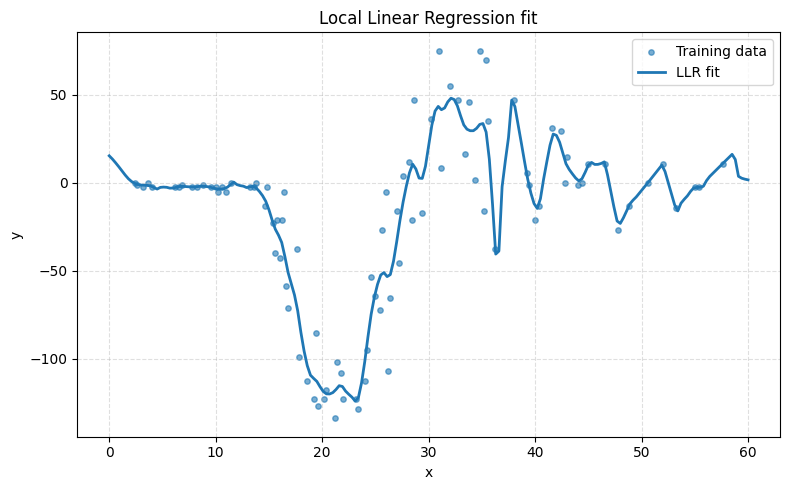

In [10]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))
# Training data (scatter)
plt.scatter(x.cpu().numpy(), y.cpu().numpy(), s=15, alpha=0.6, label="Training data")
# Local linear regression fit (line)
plt.plot(X_test.cpu().numpy(), y_hat.cpu().numpy(), linewidth=2, label="LLR fit")

plt.xlabel("x")
plt.ylabel("y")
plt.title("Local Linear Regression fit")
plt.legend()
plt.grid(True, linestyle="--", alpha=0.4)
plt.tight_layout()
plt.show()

Selected bandwidth (CV): 1.3955


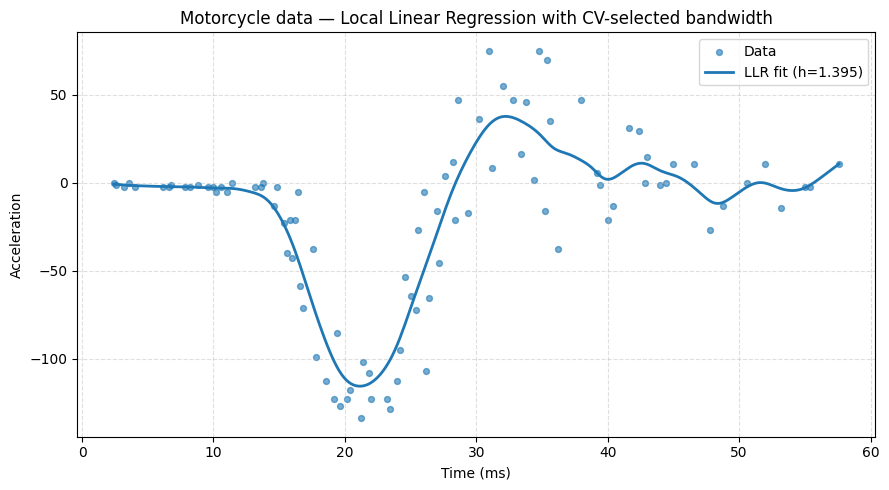

In [17]:
import numpy as np
import pandas as pd
import torch
import matplotlib.pyplot as plt

X = torch.tensor(df.times.values, dtype=torch.float64)
y = torch.tensor(df.accel.values, dtype=torch.float64)

# 2) Define a simple K-fold CV to select bandwidth h
def kfold_indices(n, n_splits=5, shuffle=True, seed=0):
    rng = np.random.default_rng(seed)
    idx = np.arange(n)
    if shuffle:
        rng.shuffle(idx)
    folds = np.array_split(idx, n_splits)
    splits = []
    for k in range(n_splits):
        val_idx = folds[k]
        train_idx = np.setdiff1d(idx, val_idx, assume_unique=False)
        splits.append((train_idx, val_idx))
    return splits

def cv_select_bandwidth(X, y, h_grid, n_splits=5, lam=1e-10):
    n = X.shape[0]
    splits = kfold_indices(n, n_splits=n_splits, shuffle=True, seed=42)
    mse_list = []
    for h in h_grid:
        fold_mse = []
        for tr, va in splits:
            # Fit on train
            llr = LocalLinearRegressor(bandwidth=float(h), lam=lam).fit(X[tr], y[tr])
            # Predict on validation
            yhat = llr.predict(X[va])
            fold_mse.append(torch.mean((yhat - y[va])**2).item())
        mse_list.append(np.mean(fold_mse))
    best_idx = int(np.argmin(mse_list))
    return float(h_grid[best_idx]), mse_list

# 3) Build a reasonable bandwidth grid relative to the spread of X
x_std = torch.std(X).item()
h_grid = torch.linspace(0.1 * x_std, 1.5 * x_std, steps=25)

best_h, cv_mse = cv_select_bandwidth(X, y, h_grid, n_splits=5)
print(f"Selected bandwidth (CV): {best_h:.4f}")

# 4) Refit on all data with best h, then predict on a dense grid
llr = LocalLinearRegressor(bandwidth=best_h).fit(X, y)
X_test = torch.linspace(X.min().item(), X.max().item(), 300)
y_hat = llr.predict(X_test)

# 5) Plot training data and the fitted curve
plt.figure(figsize=(9, 5))
plt.scatter(X.numpy(), y.numpy(), s=18, alpha=0.6, label="Data")
plt.plot(X_test.numpy(), y_hat.numpy(), linewidth=2, label=f"LLR fit (h={best_h:.3f})")
plt.xlabel("Time (ms)")
plt.ylabel("Acceleration")
plt.title("Motorcycle data — Local Linear Regression with CV-selected bandwidth")
plt.legend()
plt.grid(True, linestyle="--", alpha=0.4)
plt.tight_layout()
plt.show()
